<a href="https://colab.research.google.com/github/lilibuttler/MyDevJourney/blob/main/Agente_Teste_Dashboard.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [18]:
# 1. Instala bibliotecas necessárias (roda só na primeira vez)
!pip install openai pandas --quiet
!pip install matplotlib --quiet
!pip install gspread pandas openai --quiet
!pip install openai pandas matplotlib --quiet
!pip install gspread pandas openai --quiet

In [23]:
# agnete.py - Processa dados, gera gráfico e relatório
import pandas as pd
from openai import OpenAI
import matplotlib.pyplot as plt
import base64
import json
from datetime import datetime
from google.colab import userdata

# 1. Carrega CSV
print("📂 Lendo dados...")
dados = pd.read_csv("entregas_chatbot.csv")
if dados.empty: raise ValueError("⚠️ CSV vazio ou sem cabeçalhos.")
print(f"✅ {len(dados)} registros carregados.")

# 2. Gera gráfico
print("🎨 Gerando gráfico...")
col_dev = [c for c in dados.columns if 'dev' in c.lower() or 'desenvolvedor' in c.lower()] # Modificado para ser mais robusto
col_ent = [c for c in dados.columns if 'entrega' in c.lower()]

if col_dev and col_ent:
    dev_col, ent_col = col_dev[0], col_ent[0]
    dados[ent_col] = pd.to_numeric(dados[ent_col], errors='coerce').fillna(0)
    entregas = dados.groupby(dev_col)[ent_col].sum().sort_values(ascending=False)

    plt.figure(figsize=(8, 5))
    barras = plt.bar(entregas.index, entregas.values, color='#3b82f6')
    plt.title('Entregas por Desenvolvedor', fontsize=14)
    plt.ylabel('Total de Entregas'); plt.grid(axis='y', linestyle='--', alpha=0.3)
    for b in barras:
        plt.text(b.get_x()+b.get_width()/2, b.get_height(), f'{int(b.get_height())}', ha='center', va='bottom', fontsize=9)
    plt.tight_layout()
    plt.savefig("grafico.png", dpi=150); plt.close()
    print("✅ Gráfico salvo: grafico.png")
else:
    print("⚠️ Colunas não encontradas. Pulando gráfico.")

# 3. Gera relatório via IA
print("🤖 Chamando IA...")
with open("prompt.txt", "r", encoding="utf-8") as f: prompt = f.read()
texto_dados = dados.head(50).to_string(index=False)

client = OpenAI(api_key=userdata.get('Agente_Teste_Dashboard'))
resp = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": f"{prompt}\n\nDADOS:\n{texto_dados}"}],
    temperature=0.3
)
relatorio = resp.choices[0].message.content
print("✅ Relatório gerado.")

# 4. Gera ARQUIVO DE PONTE (JS) para o HTML
with open("grafico.png", "rb") as f:
    img_b64 = base64.b64encode(f.read()).decode()

payload = {
    "titulo": "Relatório de Desempenho - Equipe Chatbot",
    "data_geracao": datetime.now().strftime("%d/%m/%Y às %H:%M"),
    "relatorio": relatorio,
    "grafico": f"data:image/png;base64,{img_b64}"
}

# json.dumps garante que aspas e acentos não quebrem o JavaScript
js_code = f"const DASHBOARD_DATA = {json.dumps(payload, ensure_ascii=False, indent=2)};"
with open("dashboard_data.js", "w", encoding="utf-8") as f:
    f.write(js_code)

print("✅ Ponte de dados salva: dashboard_data.js")
print("📁 Próximos passos: Baixe os 3 arquivos e abra o dashboard.html")

📂 Lendo dados...
✅ 20 registros carregados.
🎨 Gerando gráfico...
✅ Gráfico salvo: grafico.png
🤖 Chamando IA...
✅ Relatório gerado.
✅ Ponte de dados salva: dashboard_data.js
📁 Próximos passos: Baixe os 3 arquivos e abra o dashboard.html


/tmp/ipykernel_21163/937617474.py:67: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_21163/937617474.py:68: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.savefig(nome_grafico, dpi=300, bbox_inches='tight')



📊 RELATÓRIO GERADO:
 # Relatório Executivo de Acompanhamento de Projetos - Período até 14 de Maio de 2026

## 1. 📊 KPIs do Período
- **% de Conclusão**: 73% das tarefas planejadas foram concluídas.
- **Tarefas Entregues**: 15 tarefas entregues, 5 pendentes.
- **Tarefas Abertas**: 5 tarefas em andamento.
- **Desvio Médio de Estimativa**: 1,5 horas (tempo real médio de 6,5 horas contra 5 horas estimadas).
- **Impacto no Cronograma**: Atrasos em 3 tarefas com impacto potencial no próximo ciclo.

## 2. ✅ Destaques
- **Integração API WhatsApp**: Concluída com 10 horas reais, 2 bugs identificados e corrigidos, impactando diretamente na comunicação com usuários.
- **Implementação de Fallback Inteligente**: Redução de respostas genéricas em 40%, melhorando a experiência do usuário e aumentando a eficiência do sistema.
- **Documentação Técnica**: Publicação de documentos no Confluence, facilitando o acesso à informação para a equipe e stakeholders.

## 3. ⚠️ Pontos de Atenção
- **Tarefas Pende

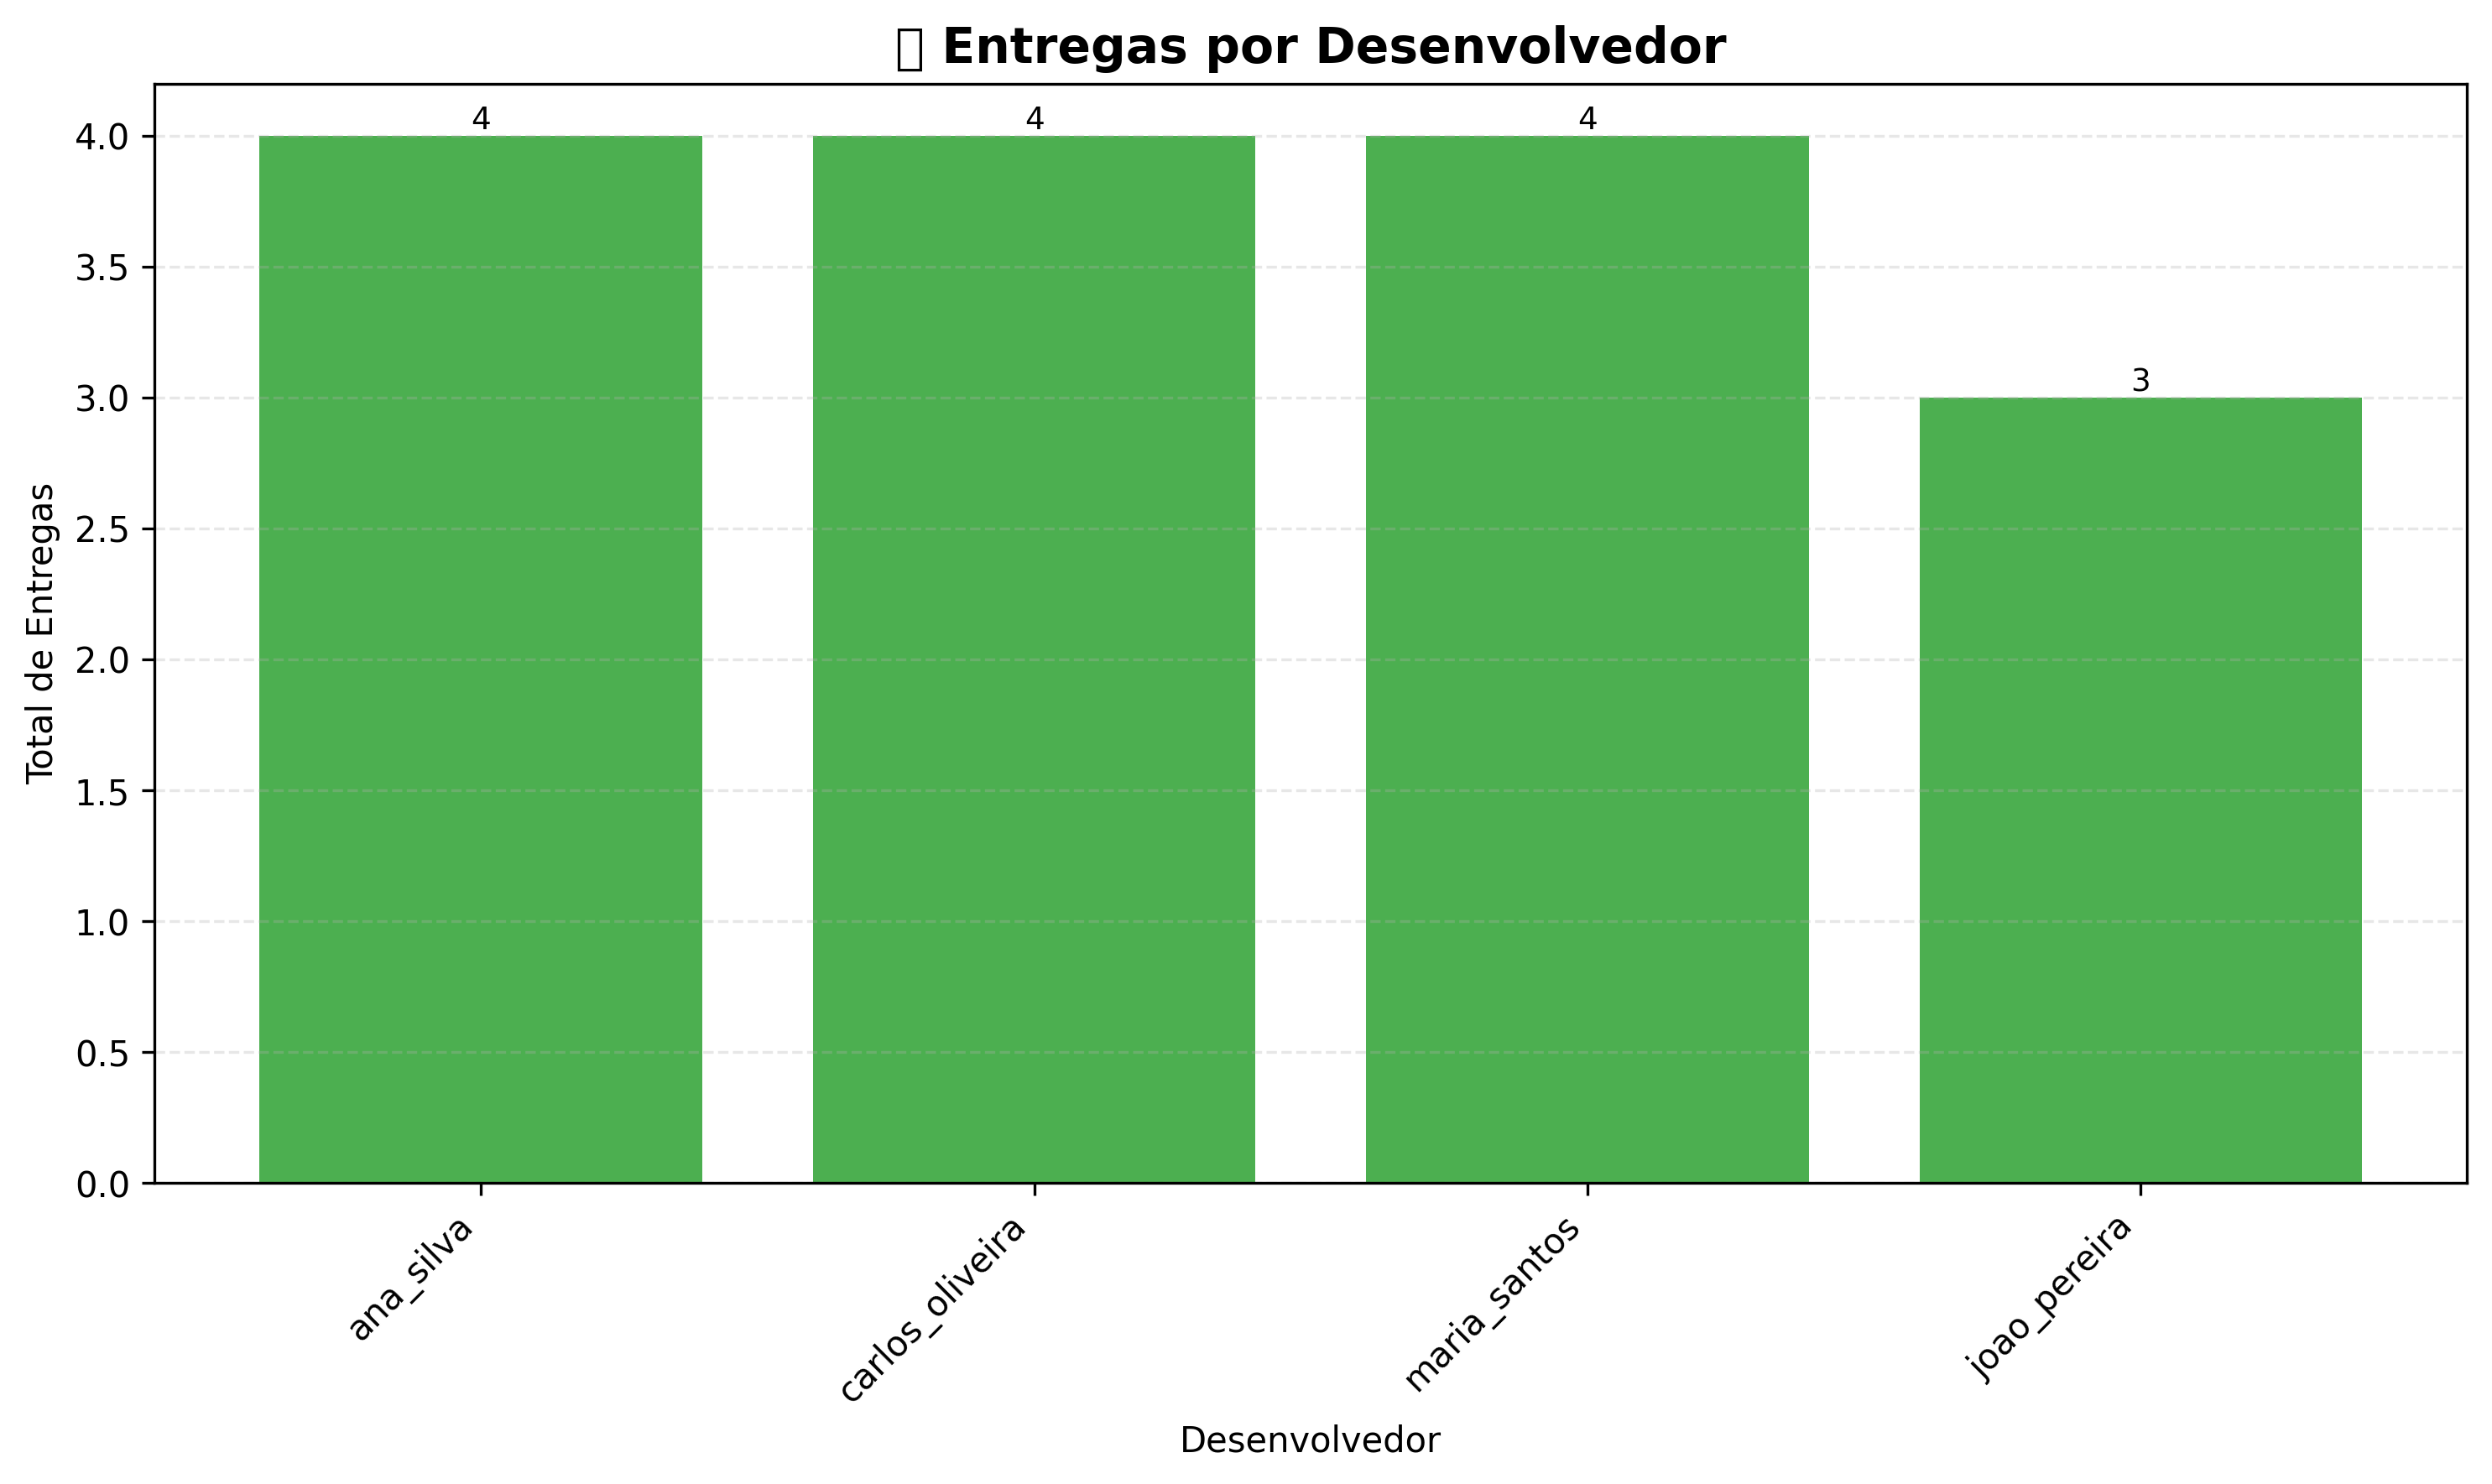

In [21]:
# v.03- CSV + Gráfico Automático + Proteções


# 1. Instala bibliotecas necessárias (roda só na primeira vez)
# !pip install openai pandas --quiet
# !pip install matplotlib --quiet
# !pip install gspread pandas openai --quiet
# !pip install openai pandas matplotlib --quiet
# !pip install gspread pandas openai --quiet

# 2. Importa ferramentas básicas
import pandas as pd
from openai import OpenAI
from datetime import datetime
import matplotlib.pyplot as plt
from google.colab import userdata

# 3. Carrega seus dados (faça upload do .csv no ícone 📁 à esquerda)
#print("📂 Lendo arquivo CSV...")
dados = pd.read_csv("entregas_chatbot.csv")

# 🔒 Proteção: evita enviar dados vazios para a IA
if dados.empty:
    raise ValueError("⚠️ O CSV está vazio ou não foi lido. Verifique se o upload está correto e se a linha 1 tem os cabeçalhos.")
#print(f"✅ {len(dados)} registros carregados.")

# 4. Transforma a planilha em texto que a IA entende
# .head(50) evita estourar o limite de tokens se o CSV for muito grande
texto_dados = dados.head(50).to_string(index=False)

# ============================================
# 🎨 GERA GRÁFICO: Entregas por Desenvolvedor
# ============================================
# print("🎨 Gerando gráfico...")
nome_grafico = "entregas_por_dev.png"
grafico_gerado = False

# Busca colunas de forma flexível (ignora maiúsculas ou nomes levemente diferentes)
col_dev = [c for c in dados.columns if 'dev' in c.lower() or 'desenvolvedor' in c.lower()]
col_entregas = [c for c in dados.columns if 'entrega' in c.lower()]

if col_dev and col_entregas:
    dev_col = col_dev[0]
    entregas_col = col_entregas[0]

    # Garante que números são tratados como números (evita erros com textos vazios)
    dados[entregas_col] = pd.to_numeric(dados[entregas_col], errors='coerce').fillna(0)

    # Agrupa por desenvolvedor e soma as entregas
    entregas_por_dev = dados.groupby(dev_col)[entregas_col].sum().sort_values(ascending=False)

    # Cria o gráfico de barras
    plt.figure(figsize=(10, 6))
    barras = plt.bar(entregas_por_dev.index, entregas_por_dev.values, color='#4CAF50')
    plt.xlabel('Desenvolvedor', fontsize=10)
    plt.ylabel('Total de Entregas', fontsize=10)
    plt.title('📦 Entregas por Desenvolvedor', fontsize=14, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)

    # Adiciona o valor exato em cima de cada barra
    for barra in barras:
        altura = barra.get_height()
        plt.text(barra.get_x() + barra.get_width()/2, altura, f'{int(altura)}',
                ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.savefig(nome_grafico, dpi=300, bbox_inches='tight')
    plt.close()  # Libera memória
    grafico_gerado = True
    # print(f"✅ Gráfico salvo como: {nome_grafico}")
else:
    # print("⚠️ Colunas 'desenvolvedor' ou 'entregas' não encontradas. Pulando gráfico.")
    pass # Adicionando 'pass' para corrigir o IndentationError
# ============================================

# Adiciona menção ao gráfico no texto enviado para a IA
if grafico_gerado:
    texto_dados += f"\n\n[GRÁFICO GERADO: {nome_grafico} - mencione no relatório que a imagem está disponível]"

# 5. Configura a IA
client = OpenAI(api_key=userdata.get('Agente_Teste_Dashboard'))

# 6. Junta o prompt + dados
with open("prompt.txt", "r", encoding="utf-8") as f:
    prompt_base = f.read()
prompt_completo = prompt_base + "\n" + texto_dados

# 7. Envia para a IA e recebe a resposta
# print("🤖 Gerando análise com IA...")
resposta = client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": prompt_completo}],
    temperature=0.3
)

# 8. Mostra e salva o resultado
relatorio = resposta.choices[0].message.content
print("\n📊 RELATÓRIO GERADO:\n", relatorio)

nome_arquivo = f"relatorio_{datetime.now().strftime('%Y-%m-%d')}.txt"
with open(nome_arquivo, "w", encoding="utf-8") as f:
    f.write(relatorio)
print(f"✅ Relatório salvo como: {nome_arquivo}")

# Mostra o gráfico na tela do Colab
if grafico_gerado:
    from IPython.display import Image, display
    print(f"\n🖼️ Visualizando gráfico:")
    display(Image(filename=nome_grafico))